## Automatic labeling
This notebook guides you through the process of labeling and exporting a first version of the dataset.
- ❗️ WARNING: This notebook assumes that you have a specific folder or set of folders which respects the example provided in `/data/folder_example.png`. See section "*2-bis Google Earth Generation*" in README for more information. 

In [ ]:
%load_ext autoreload
%autoreload 2
from pathlib import Path

from src.tools.visu_utils import display_img_with_labels, display_image_with_all_bboxes
from src.labeling.export_config import ExportConfig, DatasetTypes
from src.labeling.generate_dataset import export_datasets
from src.labeling.label_export import export_labels
from src.labeling.labels import Labels

### Creating the export configuration
This step requires to fill in the following data:
- `dataset_name` is the name you want for output, labeled dataset
- `output_directory` is where the labeled dataset will be saved

Then the method `add_dataset_for_export` allows to add a directory with possibly multiple datasets.

Troubleshoot:
- *Scenarios for which the yaml or the esp file cannot be found are skipped*
- *Scenarios for which the runway cannot be found in the runways_database are skipped (warning: runway '01' is not the same as runway '1')* 

In [ ]:
config = ExportConfig()
config.dataset_name = "yaml_test_airports"
config.output_directory = "data"
config.add_dataset_for_export(dataset_name="TestingAirports", # The name of the input dataset
                            dataset_folder = "scenarios/TestingAirports", # The folder where the input dataset should be 
                            dataset_type = DatasetTypes.EARTH_STUDIO) # Type of dataset, 
                            # either EARTH_STUDIO, REAL, FLSIM, XPLANE, ARCGIS, BING_MAPS.
                            # Except for REAL dataset, using a type will fetch the associated database 
                            # Ex: runways_db_V2_ArcGIS.json or runways_db_V2_FLSim.json
# Once the configuration is exported, export can be started
export_datasets(config)

## Advanced usage: Aggregated dataset

- Generate a SINGLE dataset from multiple scenarios directories:

In [ ]:
# config = ExportConfig()
# config.dataset_name = "test_dataset"
# config.output_directory = "data"
# config.add_dataset_for_export(dataset_name="LARD_Real",
#                               dataset_folder = "scenarios/test/LARD_Test_Real",
#                              dataset_type = DatasetTypes.REAL)
# config.add_dataset_for_export(dataset_name="LARD_Synth",
#                               dataset_folder = "scenarios/test/LARD_Test_Synth",
#                              dataset_type = DatasetTypes.EARTH_STUDIO)
# export_datasets(config)

## Sanity check

The following will guide you through verifying the export result and the associated metadata

In [ ]:
dataset_folder = Path("data/yaml_test_airports/")
labels_file = dataset_folder / "yaml_test_airports.csv"

dataset_labels = Labels(labels_file)
        
# The directory where you want to save labelled pictures (if not, put at None):
save_directory = dataset_folder / "sanity_check"

In [ ]:
# output metadata for a single element
dataset_labels.get_label(20)

Saved labeled image to data\yaml_test_airports\sanity_check\EDDF-25C-07C_LEMD-18L-00R-18R-00L-32R-14L__10-smpl__16h00_00.jpeg


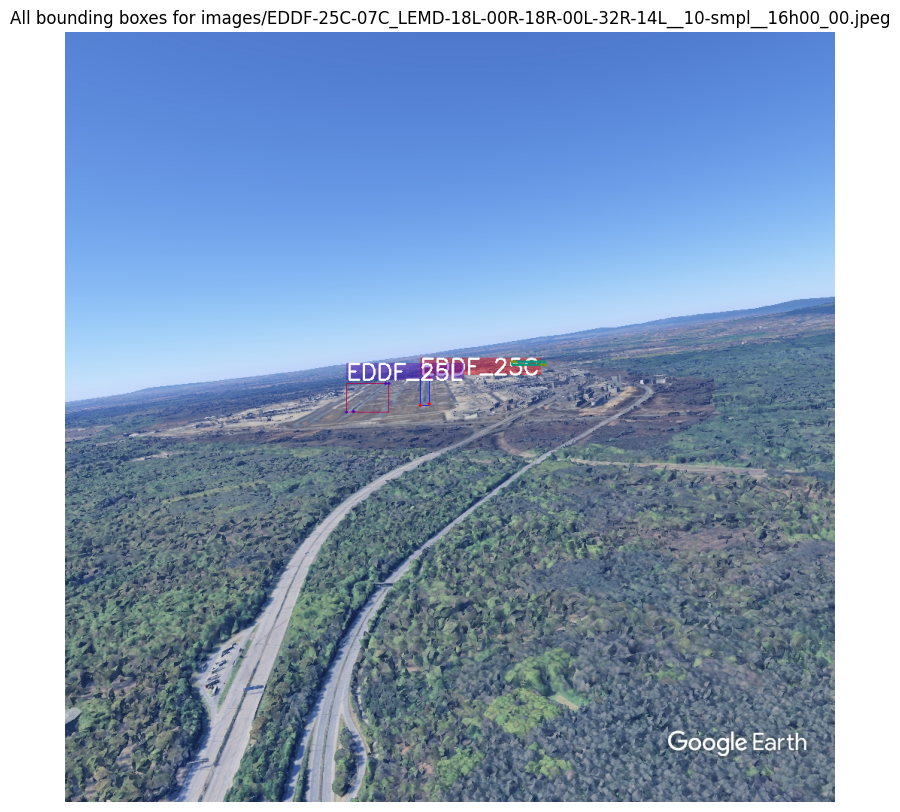

Saved labeled image to data\yaml_test_airports\sanity_check\EDDF-25C-07C_LEMD-18L-00R-18R-00L-32R-14L__10-smpl__16h00_01.jpeg


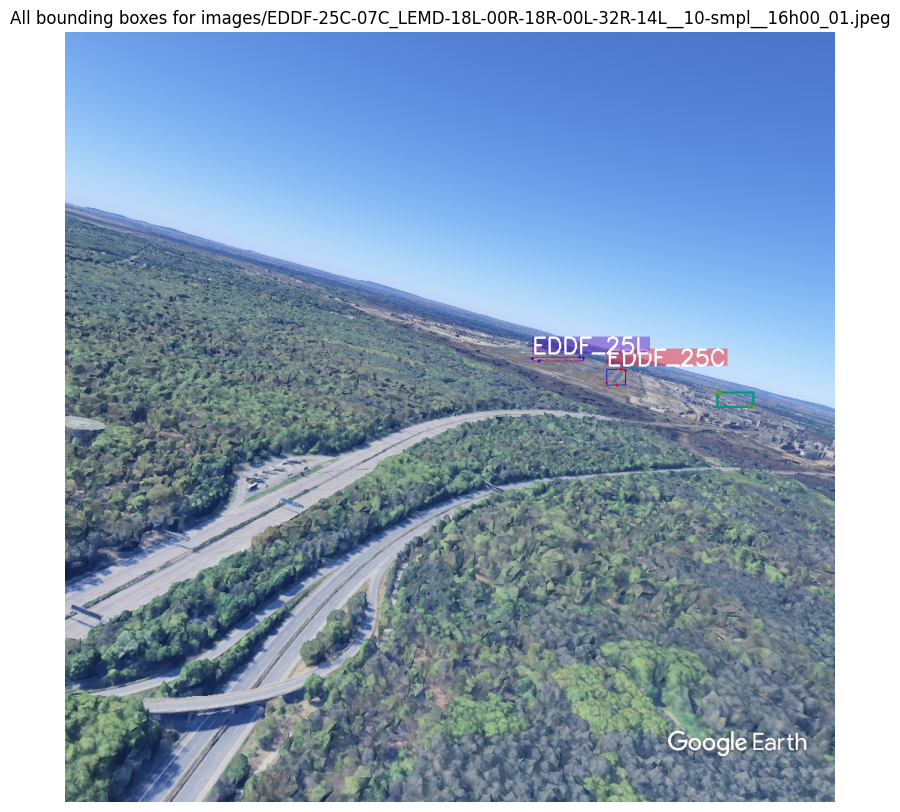

Saved labeled image to data\yaml_test_airports\sanity_check\EDDF-25C-07C_LEMD-18L-00R-18R-00L-32R-14L__10-smpl__16h00_02.jpeg


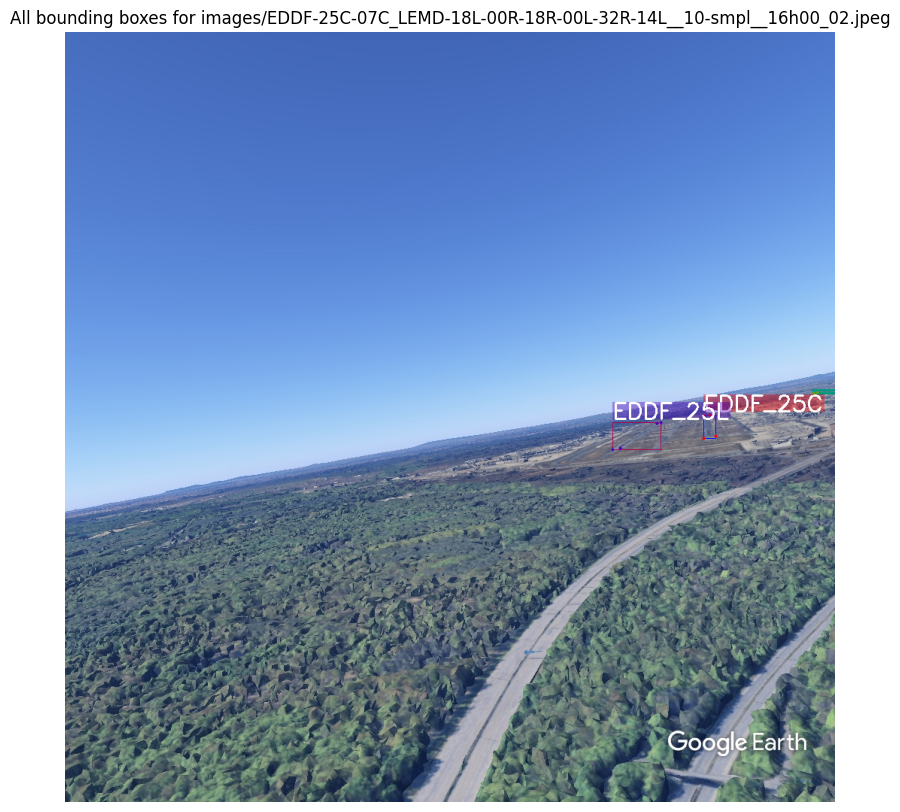

Saved labeled image to data\yaml_test_airports\sanity_check\EDDF-25C-07C_LEMD-18L-00R-18R-00L-32R-14L__10-smpl__16h00_03.jpeg


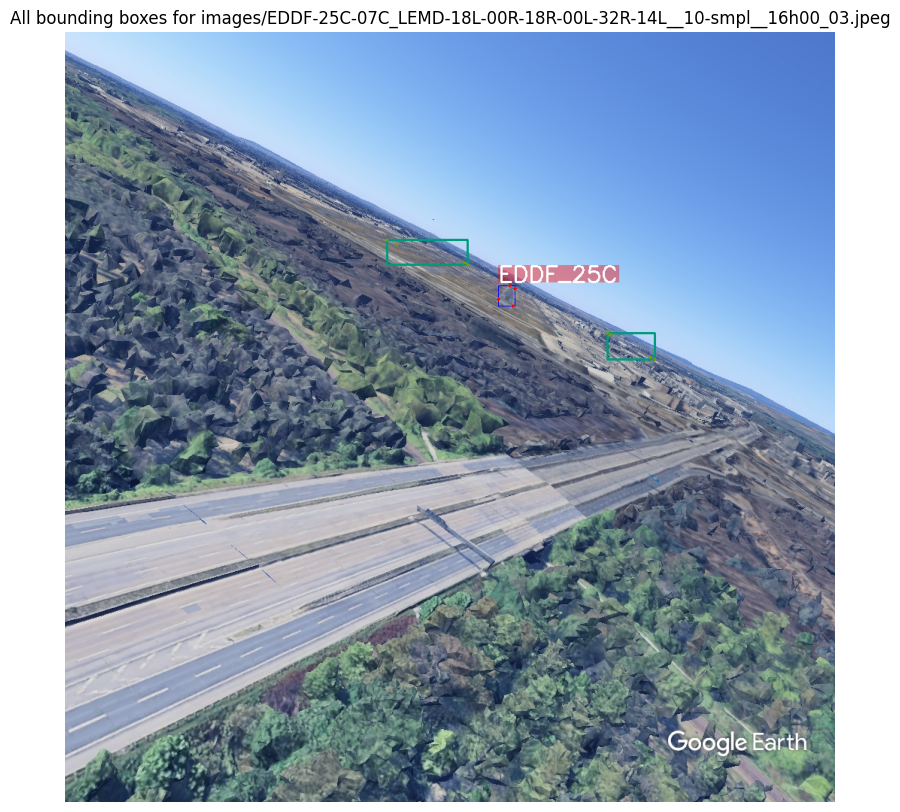

In [25]:
# The function display_image_with_all_bboxes alow to save and
for img_idx in range(0, 10, 3):
  display_image_with_all_bboxes(dataset_labels,img_idx,figsize=(10, 10),save_dir=save_directory,dataset_dir=dataset_folder,do_plot=True)
